In [8]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import subprocess

import scipy.stats
from adjustText import adjust_text

mpl.rcParams['axes.labelsize'] = 6
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['axes.titlesize'] = 6

mpl.rcParams['figure.dpi'] = 300

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'
mpl.rcParams['font.size'] = 6

mpl.rcParams['legend.fontsize'] = 5.5
mpl.rcParams['legend.framealpha'] = 0.5

mpl.rcParams['lines.linewidth'] = 1

mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.major.width'] = 1

mpl.rcParams['ytick.labelsize'] = 6
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1

mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['savefig.format'] = 'svg'
mpl.rcParams['savefig.transparent'] = True

mm = 1 / 25.4
# fig = plt.figure(constrained_layout=True, figsize=(40*mm, 50*mm))

In [9]:
from lir_proteome_screen_pssm import environment as env
import pandas as pd
import lir_proteome_screen_pssm.sequence_utils as seqtools
import re
import numpy as np
import copy
import lir_proteome_screen_pssm.data_loaders as dl
from pathlib import Path

In [4]:
import re
import numpy as np
import pandas as pd
import glob, os


In [5]:
input_pLogo_text_file = Path('./deduplicated_sequences/plogo_binomials_PSSM.txt')
with open(input_pLogo_text_file, "r") as handle:
    f = handle.readlines()
    f2 = [i.strip() for i in f]
aas, positions, scores = [], [], []
p = re.compile(r"(\w)_(.*)=(.*)]")
for i in f2:
    temp = p.findall(i)[0]
    aas.append(temp[0])
    positions.append(float(temp[1]))
    scores.append(float(temp[2]))
min_pos = min(positions)
# positions = [i - min_pos for i in positions]
positions = [i + 1 for i in positions]
pos = list(range(int(min(positions)), int(max(positions)) + 1))
mat = pd.DataFrame(columns=env.STANDARD_AMINO_ACIDS, index=pos)
for aa, p, s in zip(aas, positions, scores):
    mat.loc[int(p), aa] = s
mat.index.name = "pos"
mat = mat.reindex(sorted(mat.columns), axis=1)
mat = mat.fillna(0).copy()
mat

/var/folders/q4/k476_qrd3jvdvzwd6lq30kqc0000gn/T/ipykernel_88018/70190924.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mat = mat.fillna(0).copy()


,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
pos,,,,,,,,,,,,,,,,,,,,
-4,-0.436239,-1.191810,0.773883,0.64408,-0.504334,-0.147061,0.140585,-1.432800,-0.342901,0.642812,-0.162963,-0.326476,-0.116012,0.311098,-0.968024,1.181270,1.745090,-0.124497,0.093784,-0.277365
-3,0.140655,-0.809016,7.611740,3.34100,-0.511829,-1.228800,-0.180457,-0.029862,-0.947099,-1.431100,0.042203,-0.316468,0.414354,-0.277591,-1.539720,1.135160,-0.035263,-1.981940,-0.055298,-0.130203
-2,0.332796,-0.841876,4.426790,7.59622,-1.872260,0.226152,0.406873,-1.135790,-0.583584,-0.987036,0.042203,1.927650,-1.041130,-0.305909,-2.184960,-0.402081,-0.281308,-2.109470,-0.783198,0.126647
-1,0.330009,-1.063890,4.576820,5.10360,-0.947880,0.425334,0.240672,0.477528,-1.468240,-0.830117,-0.671827,0.199925,-0.336798,-0.043272,-1.043520,0.351491,-0.040501,-1.451720,-0.615779,-1.519180
0,0.000000,0.000000,0.000000,0.00000,-0.993842,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.119950,-1.722060
1,-0.944452,-0.601292,0.721018,18.56050,-0.370615,-0.484847,-0.645711,-0.556568,-1.315990,-1.305790,1.518610,-0.018130,0.605957,-2.428570,-1.758650,-0.743463,1.579620,-1.494860,-0.310688,-0.286538
2,-1.283190,-1.997690,2.323450,1.17156,0.587778,-0.170416,0.216083,3.463850,-0.406354,0.745755,-0.285520,-0.513217,-1.652610,-1.319810,-2.705870,0.415820,0.279342,0.257296,-0.834990,0.309327
3,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-0.080446,0.000000,1.852800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.983840,0.000000,0.000000
4,-0.524127,-2.085020,2.463150,2.08250,-0.551553,0.311709,-0.043152,-0.556011,0.056732,-0.959789,0.821181,-1.444500,0.183895,-0.980766,0.123315,0.193752,1.840120,-0.278378,0.364068,-0.693655


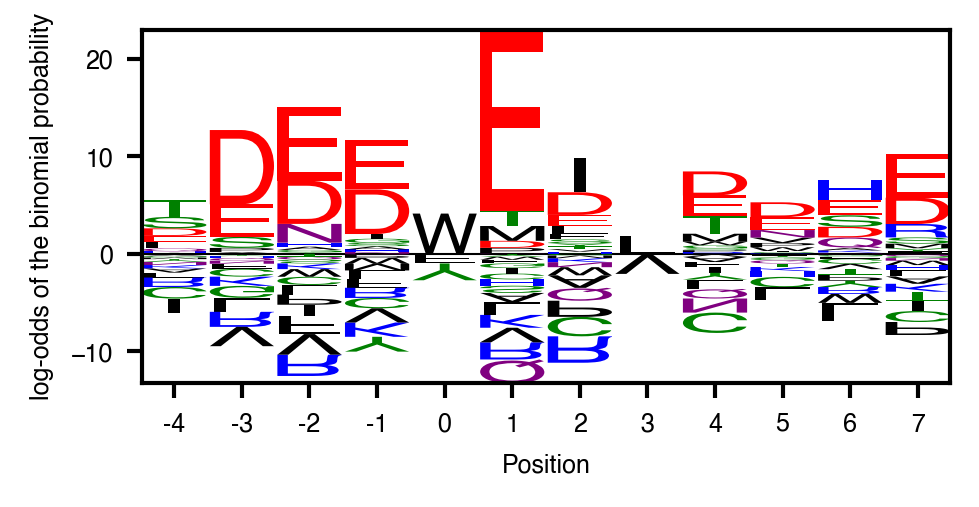

In [10]:
import lir_proteome_screen_pssm.pssms as pssms
import logomaker as lm
fig, ax = plt.subplots(figsize=(80*mm, 40*mm))
fig.set_constrained_layout(True)
pssms.plot_logo(mat, ax=ax)
ax.set_xticks(mat.index)
ax.set_xticklabels(mat.index)
ax.set_ylabel("log-odds of the binomial probability")
ax.set_xlabel("Position")
fig.savefig(input_pLogo_text_file.with_suffix('.svg'), bbox_inches='tight')

In [7]:
mat

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
pos,,,,,,,,,,,,,,,,,,,,
-4,-0.436239,-1.191810,0.773883,0.64408,-0.504334,-0.147061,0.140585,-1.432800,-0.342901,0.642812,-0.162963,-0.326476,-0.116012,0.311098,-0.968024,1.181270,1.745090,-0.124497,0.093784,-0.277365
-3,0.140655,-0.809016,7.611740,3.34100,-0.511829,-1.228800,-0.180457,-0.029862,-0.947099,-1.431100,0.042203,-0.316468,0.414354,-0.277591,-1.539720,1.135160,-0.035263,-1.981940,-0.055298,-0.130203
-2,0.332796,-0.841876,4.426790,7.59622,-1.872260,0.226152,0.406873,-1.135790,-0.583584,-0.987036,0.042203,1.927650,-1.041130,-0.305909,-2.184960,-0.402081,-0.281308,-2.109470,-0.783198,0.126647
-1,0.330009,-1.063890,4.576820,5.10360,-0.947880,0.425334,0.240672,0.477528,-1.468240,-0.830117,-0.671827,0.199925,-0.336798,-0.043272,-1.043520,0.351491,-0.040501,-1.451720,-0.615779,-1.519180
0,0.000000,0.000000,0.000000,0.00000,-0.993842,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.119950,-1.722060
1,-0.944452,-0.601292,0.721018,18.56050,-0.370615,-0.484847,-0.645711,-0.556568,-1.315990,-1.305790,1.518610,-0.018130,0.605957,-2.428570,-1.758650,-0.743463,1.579620,-1.494860,-0.310688,-0.286538
2,-1.283190,-1.997690,2.323450,1.17156,0.587778,-0.170416,0.216083,3.463850,-0.406354,0.745755,-0.285520,-0.513217,-1.652610,-1.319810,-2.705870,0.415820,0.279342,0.257296,-0.834990,0.309327
3,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-0.080446,0.000000,1.852800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.983840,0.000000,0.000000
4,-0.524127,-2.085020,2.463150,2.08250,-0.551553,0.311709,-0.043152,-0.556011,0.056732,-0.959789,0.821181,-1.444500,0.183895,-0.980766,0.123315,0.193752,1.840120,-0.278378,0.364068,-0.693655
